# Application 3 — Segmentation Transfer

A **segmentation** is a per-vertex integer label (body part, anatomical region, tissue type).
Once we have a point-to-point correspondence, transferring a segmentation is a single index operation:
`seg_b[i] = seg_a[p2p[i]]`.

This notebook uses cat → lion as placeholder.
**To use brain or organ shapes**: replace the data loading section and the
segmentation definition with your own labels.
The rest of the pipeline is identical.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

from geomfum.dataset import NotebooksDataset
from geomfum.shape import TriangleMesh

pv.set_jupyter_backend("static")


def to_pv(mesh):
    faces = np.hstack([np.full((len(mesh.faces), 1), 3), mesh.faces])
    return pv.PolyData(np.array(mesh.vertices), faces)

## 1. Load shapes


In [2]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(
    dataset.get_filename("brain_template")
)  # source with known landmarks
mesh_b = TriangleMesh.from_file(dataset.get_filename("brain_subject"))  # target
# centering
mesh_a.vertices -= mesh_a.vertices.mean(axis=0)
mesh_b.vertices -= mesh_b.vertices.mean(axis=0)
label_a = np.loadtxt(dataset.get_filename("template_labels")).astype(int)

## 2. Compute correspondence (FM pipeline)

In [3]:
from geomfum.convert import FmFromP2pConverter, NeighborFinder

knn = NeighborFinder()
p2p = knn(mesh_b.vertices, mesh_a.vertices).flatten()

## 3. Transfer segmentation to the target

In [5]:
label_b = label_a[p2p]  # single index operation — that's it

## 5. Visualise segmentation on both shapes

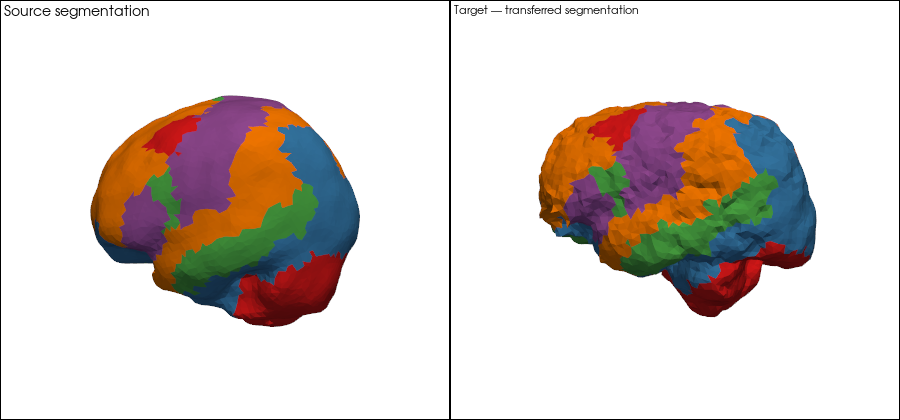

In [6]:
unique_a = np.unique(label_a)
unique_b = np.unique(label_b)

all_labels = np.union1d(unique_a, unique_b)
remap = {v: i for i, v in enumerate(all_labels)}
label_a_r = np.vectorize(remap.get)(label_a)
label_b_r = np.vectorize(remap.get)(label_b)

n_labels = len(all_labels)
cmap = plt.get_cmap("Set1", n_labels)


def vertex_to_face_labels(faces, vertex_labels):
    """Assign each face the label of its first vertex (majority vote avoids blending)."""
    return vertex_labels[faces[:, 0]].astype(float)


pl = pv.Plotter(shape=(1, 2), window_size=(900, 420))

pv_a = to_pv(mesh_a)
pv_a.cell_data["seg"] = vertex_to_face_labels(mesh_a.faces, label_a_r)
pl.subplot(0, 0)
pl.add_mesh(
    pv_a, scalars="seg", cmap=cmap, clim=(-0.5, n_labels - 0.5), show_scalar_bar=False
)
pl.add_text("Source segmentation", font_size=9)
pl.camera_position = "yz"

pv_b = to_pv(mesh_b)
pv_b.cell_data["seg"] = vertex_to_face_labels(mesh_b.faces, label_b_r)
pl.subplot(0, 1)
pl.add_mesh(
    pv_b, scalars="seg", cmap=cmap, clim=(-0.5, n_labels - 0.5), show_scalar_bar=False
)
pl.add_text("Target — transferred segmentation", font_size=9)
pl.camera_position = "yz"

pl.show()


Corresponding anatomical regions should carry the same color on both shapes.
Errors (miscolored patches) reflect local inaccuracies in the FM correspondence.